# 03 — Analisis & Figure

Tabel hasil, tiga figure, dan validasi parser terhadap output mentah.

**Prasyarat**
1. Add Data → dataset berisi `results/results.csv`; bagian 5–6 juga butuh
   `adapters/` dan `data/processed/`
2. Accelerator: **None** untuk bagian 1–4, **GPU** untuk bagian 5–6

Bagian 1–4 murni CPU sehingga figure bisa diiterasi tanpa memakai kuota GPU.

In [40]:
import glob, json, re
from pathlib import Path
import numpy as np, pandas as pd

cands = sorted(glob.glob("/kaggle/working/results/results_v2.csv"))
assert cands, "results.csv tidak ketemu. Add Data -> dataset hasil notebook 02."
df = pd.read_csv(cands[0])
print("sumber:", cands[0])

OUT = Path("/kaggle/working/results"); (OUT/"figures").mkdir(parents=True, exist_ok=True)

VARIANTS = ["G1", "G2", "G3"]
SHORT = {"unsloth/Qwen3-0.6B": "Qwen3-0.6B", "unsloth/Qwen3-1.7B": "Qwen3-1.7B"}

n_fin = len(df[df.variant.isin(VARIANTS + ["AO"])])
n_base = len(df[df.variant == "pre-distill"])
print(f"{len(df)} baris: {n_fin} run fine-tune + {n_base} baseline")
assert n_fin == 14 and n_base == 2, f"harusnya 14+2, dapat {n_fin}+{n_base}"
assert df.run_id.is_unique, "ada run_id duplikat"
assert df[df.variant.isin(VARIANTS+["AO"])].n_train.nunique() == 1, \
    "N train berbeda antar run — perbandingan tidak sah"
print("integritas results.csv: OK")

sumber: /kaggle/working/results/results_v2.csv
16 baris: 14 run fine-tune + 2 baseline
integritas results.csv: OK


## 1. Tabel hasil

Ini tabel yang masuk ke seksi Results README. Setiap klaim di README harus
punya angka di sini (PRD §7.3).

In [41]:
d = df[df.variant.isin(VARIANTS + ["AO"])].copy(); d["model"] = d.model.map(SHORT)
b = df[df.variant == "pre-distill"].copy();       b["model"] = b.model.map(SHORT)
base     = dict(zip(b.model, b.accuracy * 100))
base_tok = dict(zip(b.model, b.avg_output_tokens))

tbl = (d.groupby(["model", "variant"])
        .agg(acc=("accuracy", lambda s: s.mean()*100),
             sd=("accuracy", lambda s: s.std(ddof=1)*100 if len(s) > 1 else np.nan),
             tok=("avg_output_tokens", "mean"),
             lat=("latency_s_per_item", "mean"),
             loss=("train_loss", "mean"),
             n_seed=("accuracy", "size")).reset_index())
tbl["vs_baseline"] = tbl.apply(lambda r: r.acc - base[r.model], axis=1)
tbl["acc_per_100tok"] = tbl.acc / tbl.tok * 100
tbl = tbl.round(2)
tbl.to_csv(OUT/"summary_table.csv", index=False)
display(tbl)
print("\nbaseline pre-distillation:", {k: round(v, 2) for k, v in base.items()})

,model,variant,acc,sd,tok,lat,loss,n_seed,vs_baseline,acc_per_100tok
0,Qwen3-0.6B,AO,12.33,NaN,5.40,0.05,0.39,1,-23.00,228.40
1,Qwen3-0.6B,G1,43.67,0.94,42.43,0.50,0.17,2,8.33,102.92
2,Qwen3-0.6B,G2,56.67,0.94,97.00,1.06,0.32,2,21.33,58.42
3,Qwen3-0.6B,G3,59.33,2.83,374.70,6.38,0.47,2,24.00,15.84
4,Qwen3-1.7B,AO,20.00,NaN,5.42,0.08,0.45,1,-52.67,369.00
5,Qwen3-1.7B,G1,58.67,0.94,40.27,0.60,0.17,2,-14.00,145.70
6,Qwen3-1.7B,G2,73.83,1.18,96.36,1.47,0.29,2,1.17,76.62
7,Qwen3-1.7B,G3,78.67,2.83,364.18,6.91,0.41,2,6.00,21.60


baseline pre-distillation: {'Qwen3-0.6B': 35.33, 'Qwen3-1.7B': 72.67}


### Uji hipotesis PRD §7.1

Dilaporkan apa adanya, termasuk yang tidak terdukung.

In [42]:
def m(model, v): return tbl[(tbl.model == model) & (tbl.variant == v)].acc.iloc[0]
def s(model, v):
    x = tbl[(tbl.model == model) & (tbl.variant == v)].sd.iloc[0]
    return 0.0 if pd.isna(x) else x

for h, ok, note in [
    ("H1  0.6B puncak di G1/G2, bukan G3",
     max(VARIANTS, key=lambda v: m("Qwen3-0.6B", v)) in ("G1", "G2"),
     f"puncak di {max(VARIANTS, key=lambda v: m('Qwen3-0.6B', v))}"),
    ("H2  puncak 1.7B lebih tinggi dari 0.6B",
     VARIANTS.index(max(VARIANTS, key=lambda v: m("Qwen3-1.7B", v)))
     > VARIANTS.index(max(VARIANTS, key=lambda v: m("Qwen3-0.6B", v))),
     "keduanya puncak di level yang sama"),
    ("H3  semua CoT > answer-only",
     all(m(mo, v) > m(mo, "AO") for mo in SHORT.values() for v in VARIANTS),
     f"selisih terkecil {min(m(mo,v)-m(mo,'AO') for mo in SHORT.values() for v in VARIANTS):.1f} pp"),
    ("H4  G3 jauh lebih mahal, gain kecil",
     all(m(mo, "G3") - m(mo, "G2") < 5 for mo in SHORT.values()),
     " | ".join(f"{mo}: {tbl[(tbl.model==mo)&(tbl.variant=='G3')].tok.iloc[0]/tbl[(tbl.model==mo)&(tbl.variant=='G2')].tok.iloc[0]:.1f}x token, "
                f"{m(mo,'G3')-m(mo,'G2'):+.2f} pp" for mo in SHORT.values())),
]:
    print(f"[{'DIDUKUNG' if ok else '  TIDAK  '}] {h}\n              {note}")

print("\n--- G2 vs G3 dibanding sebaran seed ---")
for mo in SHORT.values():
    diff = m(mo, "G3") - m(mo, "G2"); noise = max(s(mo, v) for v in VARIANTS)
    print(f"  {mo}: selisih {diff:+.2f} pp | sd seed terbesar {noise:.2f} pp -> "
          f"{'DI DALAM sebaran' if abs(diff) <= 2*noise else 'di luar sebaran'}")
print("\n  n=2 seed: ini indikasi arah, BUKAN uji signifikansi.")

[  TIDAK  ] H1  0.6B puncak di G1/G2, bukan G3
              puncak di G3
[  TIDAK  ] H2  puncak 1.7B lebih tinggi dari 0.6B
              keduanya puncak di level yang sama
[DIDUKUNG] H3  semua CoT > answer-only
              selisih terkecil 31.3 pp
[DIDUKUNG] H4  G3 jauh lebih mahal, gain kecil
              Qwen3-0.6B: 3.9x token, +2.66 pp | Qwen3-1.7B: 3.8x token, +4.84 pp

--- G2 vs G3 dibanding sebaran seed ---
  Qwen3-0.6B: selisih +2.66 pp | sd seed terbesar 2.83 pp -> DI DALAM sebaran
  Qwen3-1.7B: selisih +4.84 pp | sd seed terbesar 2.83 pp -> DI DALAM sebaran

  n=2 seed: ini indikasi arah, BUKAN uji signifikansi.


## 2. Figure

Palet dari `dataviz` dan sudah divalidasi (`validate_palette.js`): slot 1/2/3,
seluruh check PASS pada surface terang maupun gelap. Aqua di Figure 3 berada di
bawah 3:1 pada surface terang → aturan relief dipenuhi dengan label nilai di
setiap batang.

Versi terang dan gelap dibuat keduanya, supaya README bisa memakai `<picture>`
dan figure tidak menyilaukan di GitHub dark mode.

In [43]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path

VARIANTS = ["G1", "G2", "G3"]
SHORT = {"unsloth/Qwen3-0.6B": "Qwen3-0.6B", "unsloth/Qwen3-1.7B": "Qwen3-1.7B"}

# palet tervalidasi (scripts/validate_palette.js): slot 1/2/3, semua check PASS.
# aqua 2.74:1 di surface terang -> aturan relief: label nilai wajib di Fig 3.
THEMES = {
    "light": dict(surface="#fcfcfb", s1="#2a78d6", s2="#eb6834", s3="#1baf7a",
                  ink="#0b0b0b", ink2="#52514e", muted="#898781",
                  grid="#e1e0d9", axis="#c3c2b7"),
    "dark":  dict(surface="#1a1a19", s1="#3987e5", s2="#d95926", s3="#199e70",
                  ink="#ffffff", ink2="#c3c2b7", muted="#898781",
                  grid="#2c2c2a", axis="#383835"),
}


def style(T):
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
        "figure.facecolor": T["surface"], "axes.facecolor": T["surface"],
        "savefig.facecolor": T["surface"],
        "text.color": T["ink"], "axes.labelcolor": T["ink2"],
        "xtick.color": T["muted"], "ytick.color": T["muted"],
        "axes.edgecolor": T["axis"], "axes.linewidth": 0.8,
        "grid.color": T["grid"], "grid.linewidth": 0.8, "grid.linestyle": "-",
        "xtick.direction": "out", "ytick.direction": "out",
        "font.size": 10, "axes.titlesize": 12, "legend.fontsize": 9,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def agg(df):
    """mean/std akurasi (%) per model x varian, + baseline per model."""
    d = df[df.variant.isin(VARIANTS + ["AO"])].copy()
    d["model"] = d.model.map(SHORT)
    g = d.groupby(["model", "variant"]).agg(
        acc=("accuracy", lambda s: s.mean() * 100),
        sd=("accuracy", lambda s: s.std(ddof=1) * 100 if len(s) > 1 else np.nan),
        tok=("avg_output_tokens", "mean"), n=("accuracy", "size")).reset_index()
    b = df[df.variant == "pre-distill"].copy()
    b["model"] = b.model.map(SHORT)
    base = dict(zip(b.model, b.accuracy * 100))
    base_tok = dict(zip(b.model, b.avg_output_tokens))
    return g, base, base_tok


def fig1(g, base, T, path):
    """Akurasi vs granularity. Figure utama. Garis baseline = ambang, bukan grid."""
    from matplotlib.lines import Line2D
    style(T)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=200)
    x = np.arange(len(VARIANTS))
    handles = []
    for model, c in [("Qwen3-0.6B", T["s1"]), ("Qwen3-1.7B", T["s2"])]:
        s = g[(g.model == model) & (g.variant.isin(VARIANTS))].set_index("variant").loc[VARIANTS]
        ax.errorbar(x, s.acc, yerr=s.sd, color=c, lw=2, marker="o", ms=8,
                    capsize=4, elinewidth=1.4,
                    markeredgecolor=T["surface"], markeredgewidth=2, zorder=3)
        ax.axhline(base[model], color=c, lw=1.2, ls=(0, (5, 4)), alpha=.75, zorder=1)
        # label ambang di kiri, DI ATAS garis -> tidak tertimpa garis maupun legend
        ax.annotate(f"tanpa distilasi  {base[model]:.1f}%", xy=(-.3, base[model]),
                    xytext=(0, 4), textcoords="offset points",
                    fontsize=8, color=c, va="bottom", ha="left")
        ax.annotate(f"{s.acc.iloc[-1]:.1f}%", xy=(x[-1], s.acc.iloc[-1]),
                    xytext=(8, 6), textcoords="offset points",
                    fontsize=9, color=T["ink"], fontweight="bold")
        handles.append(Line2D([], [], color=c, lw=2, marker="o", ms=7,
                              markeredgecolor=T["surface"], markeredgewidth=1.5, label=model))
    ax.set_xticks(x, VARIANTS)
    ax.set_xlabel("Granularity rationale  (ringkas → sangat rinci)")
    ax.set_ylabel("Akurasi GSM8K (%)")
    ax.set_title("Akurasi vs granularity CoT di bawah QLoRA", color=T["ink"], pad=12, loc="left")
    ax.set_ylim(30, 86); ax.set_xlim(-.35, 2.35)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.legend(handles=handles, frameon=False, loc="upper left", labelcolor=T["ink2"])
    fig.text(.01, .01, "error bar = sd 2 seed  ·  garis putus = student sebelum distilasi",
             fontsize=7.5, color=T["muted"])
    fig.tight_layout(rect=(0, .03, 1, 1)); fig.savefig(path, bbox_inches="tight"); plt.close(fig)


def fig2(g, base, base_tok, T, path):
    """Biaya token vs akurasi. Semua konfigurasi, termasuk AO dan baseline."""
    from matplotlib.lines import Line2D
    style(T)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=200)
    # label ke KANAN titik: menghindari tabrakan vertikal yang muncul saat di bawah
    OFF = {("Qwen3-1.7B", "G2"): (-11, 5, "right")}      # dekat bintang 1.7B
    handles = []
    for model, c in [("Qwen3-0.6B", T["s1"]), ("Qwen3-1.7B", T["s2"])]:
        s = g[g.model == model]
        ax.scatter(s.tok, s.acc, s=90, color=c, zorder=3,
                   edgecolor=T["surface"], linewidth=2)
        for _, r in s.iterrows():
            dx, dy, ha = OFF.get((model, r.variant), (11, 0, "left"))
            ax.annotate(r.variant, xy=(r.tok, r.acc), xytext=(dx, dy),
                        textcoords="offset points", fontsize=8.5,
                        color=T["ink2"], ha=ha, va="center")
        ax.scatter([base_tok[model]], [base[model]], s=240, marker="*", color=c,
                   zorder=3, edgecolor=T["surface"], linewidth=1.5)
        handles.append(Line2D([], [], color=c, marker="o", ms=8, ls="none",
                              markeredgecolor=T["surface"], markeredgewidth=1.5, label=model))
    handles.append(Line2D([], [], color=T["muted"], marker="*", ms=13, ls="none",
                          label="tanpa distilasi"))
    ax.set_xlabel("Rata-rata token output saat inference  (biaya)")
    ax.set_ylabel("Akurasi GSM8K (%)")
    ax.set_title("Harga akurasi dalam token", color=T["ink"], pad=12, loc="left")
    ax.grid(True); ax.set_axisbelow(True)
    ax.set_xlim(-30, 420); ax.set_ylim(5, 88)
    ax.legend(handles=handles, frameon=False, loc="lower right", labelcolor=T["ink2"])
    fig.text(.01, .01, "bintang = student sebelum distilasi  ·  kiri-atas = lebih efisien",
             fontsize=7.5, color=T["muted"])
    fig.tight_layout(rect=(0, .03, 1, 1)); fig.savefig(path, bbox_inches="tight"); plt.close(fig)


def fig3(g, base, T, path):
    """Baseline vs answer-only vs CoT terbaik. Label nilai wajib (aturan relief aqua)."""
    style(T)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=200)
    models = ["Qwen3-0.6B", "Qwen3-1.7B"]
    x, w = np.arange(len(models)), 0.20
    series = []
    for m in models:
        s = g[g.model == m].set_index("variant")
        bestv = s.loc[VARIANTS].acc.idxmax()
        series.append((base[m], s.loc["AO"].acc, s.loc[bestv].acc, bestv))
    bests = sorted({row[3] for row in series})
    labels = ["Tanpa distilasi", "Answer-only", f"CoT terbaik ({'/'.join(bests)})"]
    for i, (c, key) in enumerate([(T["s1"], 0), (T["s2"], 1), (T["s3"], 2)]):
        vals = [row[key] for row in series]
        bars = ax.bar(x + (i - 1) * (w + .02), vals, w, color=c, label=labels[i],
                      edgecolor=T["surface"], linewidth=2, zorder=3)
        for b, v in zip(bars, vals):     # label nilai wajib: aturan relief aqua (2.74:1)
            ax.annotate(f"{v:.1f}", xy=(b.get_x() + b.get_width() / 2, v),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", fontsize=8.5, color=T["ink"], fontweight="bold")
    ax.set_xticks(x, models)
    ax.set_ylabel("Akurasi GSM8K (%)")
    ax.set_title("Apakah distilasi menambah nilai?", color=T["ink"], pad=12, loc="left")
    ax.set_ylim(0, 92)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=3, loc="upper left", labelcolor=T["ink2"])
    fig.text(.01, .01, "answer-only jatuh jauh di bawah student yang tak dilatih sama sekali",
             fontsize=7.5, color=T["muted"])
    fig.tight_layout(rect=(0, .03, 1, 1)); fig.savefig(path, bbox_inches="tight"); plt.close(fig)


def build_all(df, outdir):
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    g, base, base_tok = agg(df)
    made = []
    for mode, T in THEMES.items():
        sfx = "" if mode == "light" else "_dark"
        fig1(g, base, T, outdir / f"fig1_accuracy_vs_granularity{sfx}.png")
        fig2(g, base, base_tok, T, outdir / f"fig2_token_cost{sfx}.png")
        fig3(g, base, T, outdir / f"fig3_baseline{sfx}.png")
        made += [f"fig{i}{sfx}" for i in (1, 2, 3)]
    return g, base, made

dibuat: 6 file


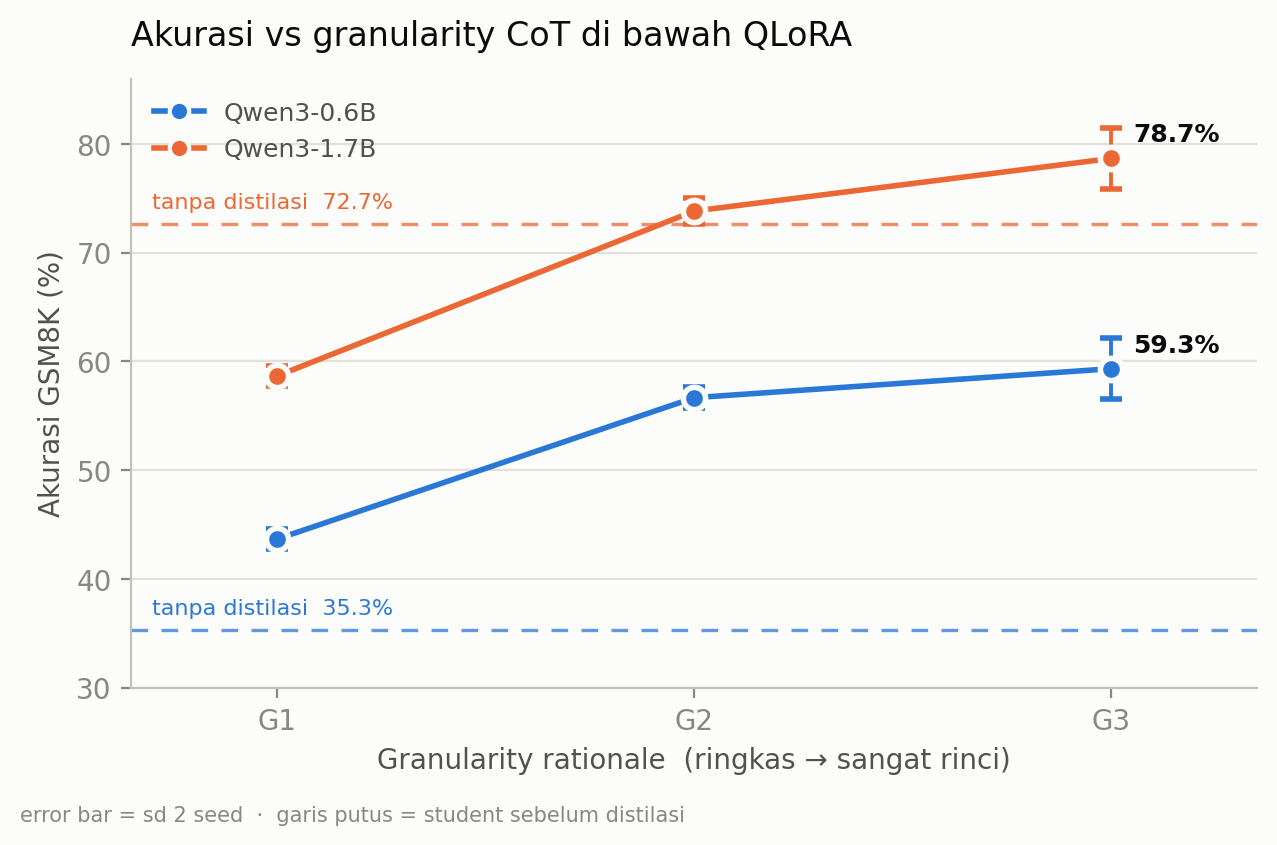

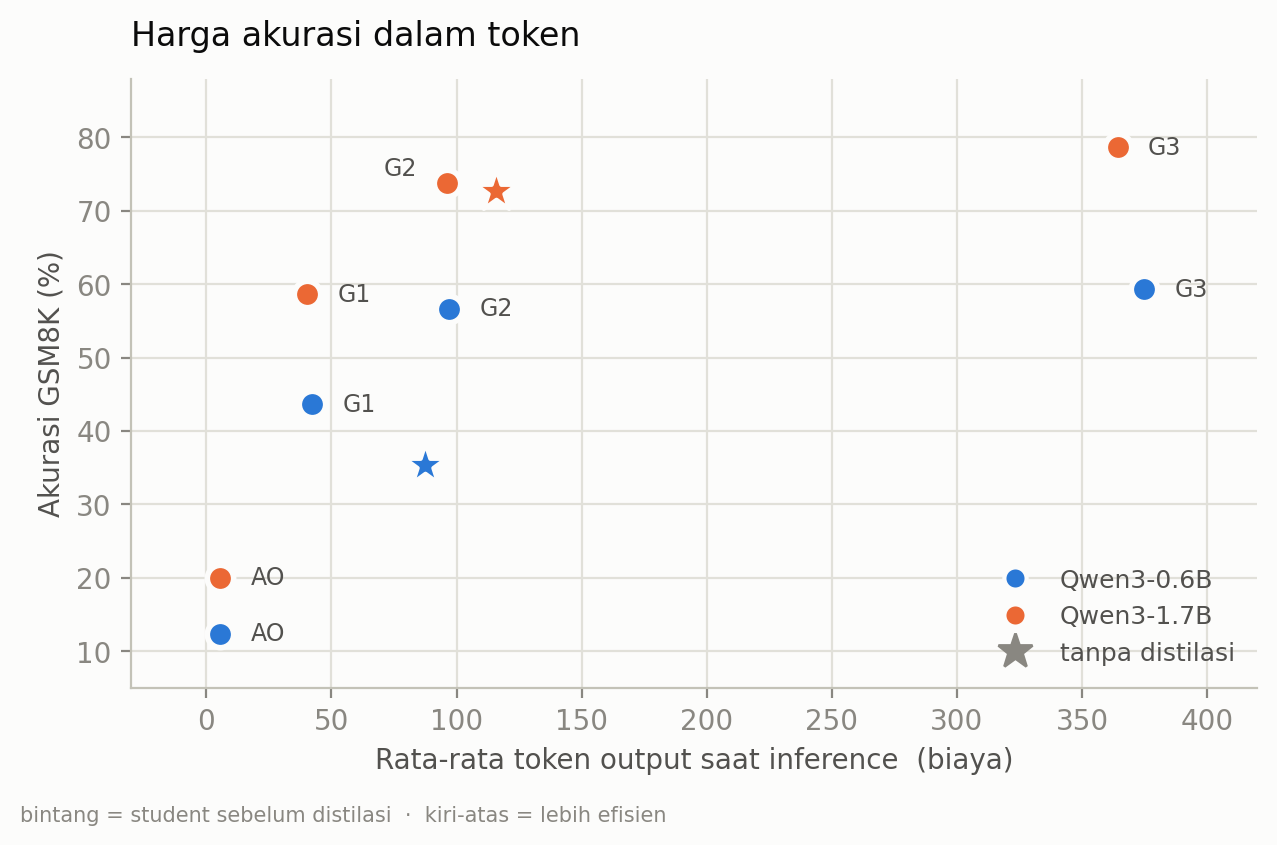

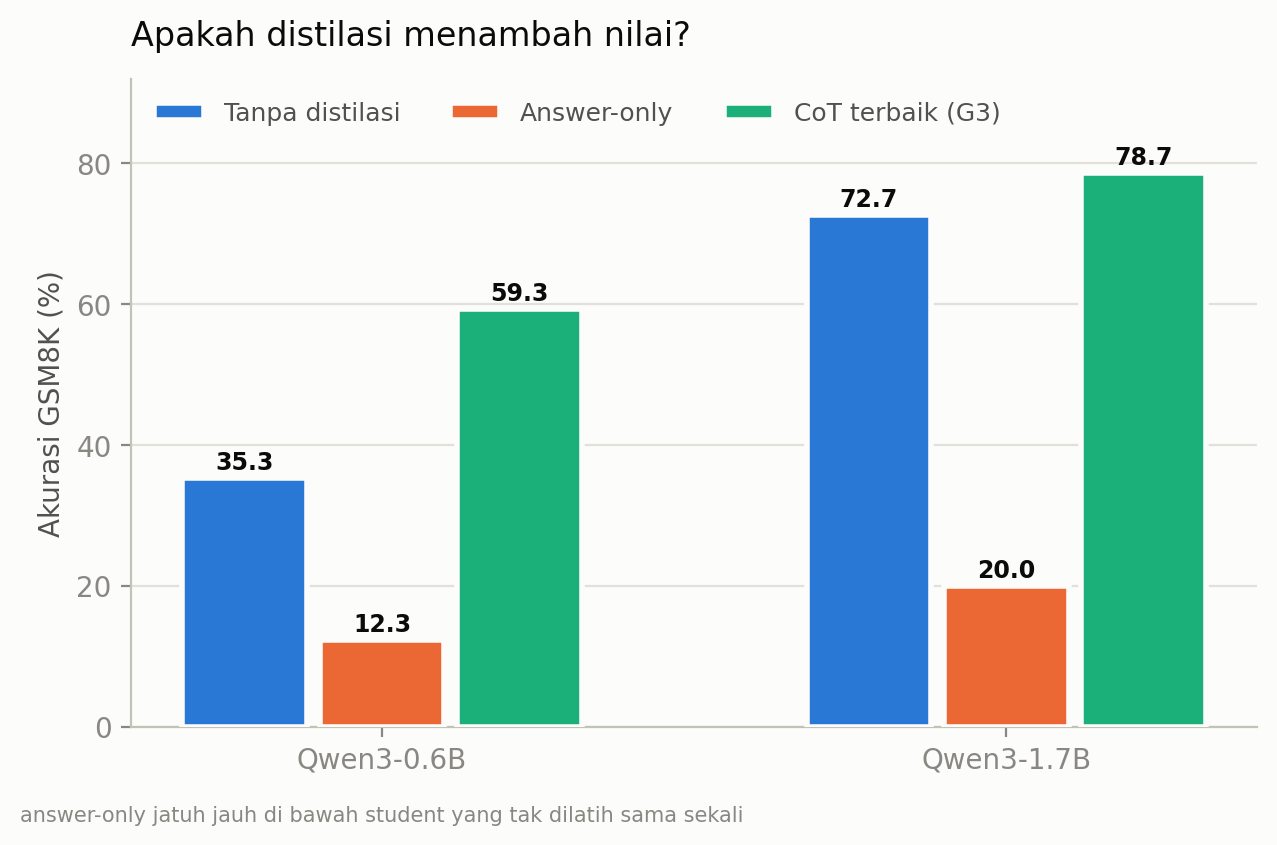

In [44]:
from IPython.display import Image, display as disp
g, base_, made = build_all(df, OUT/"figures")
print("dibuat:", len(made), "file\n")
for f in ["fig1_accuracy_vs_granularity", "fig2_token_cost", "fig3_baseline"]:
    disp(Image(filename=str(OUT/"figures"/f"{f}.png")))

## 3. Blok markdown untuk README

Ditempel langsung ke README — tidak ada angka yang diketik ulang manual.

In [45]:
lines = ["| Student | Varian | Akurasi (%) | sd | Token output | Acc/100 token | vs baseline |",
         "|---|---|---|---|---|---|---|"]
for mo in SHORT.values():
    lines.append(f"| **{mo}** | *tanpa distilasi* | *{base[mo]:.2f}* | — | *{base_tok[mo]:.1f}* | "
                 f"*{base[mo]/base_tok[mo]*100:.1f}* | — |")
    for v in ["AO"] + VARIANTS:
        r = tbl[(tbl.model == mo) & (tbl.variant == v)].iloc[0]
        sd = "—" if pd.isna(r.sd) else f"{r.sd:.2f}"
        lines.append(f"| | {v} | {r.acc:.2f} | {sd} | {r.tok:.1f} | {r.acc_per_100tok:.1f} | "
                     f"{r.vs_baseline:+.2f} |")
readme = "\n".join(lines)
(OUT/"readme_table.md").write_text(readme, encoding="utf-8")
print(readme)

| Student | Varian | Akurasi (%) | sd | Token output | Acc/100 token | vs baseline |
|---|---|---|---|---|---|---|
| **Qwen3-0.6B** | *tanpa distilasi* | *35.33* | — | *87.4* | *40.4* | — |
| | AO | 12.33 | — | 5.4 | 228.4 | -23.00 |
| | G1 | 43.67 | 0.94 | 42.4 | 102.9 | +8.33 |
| | G2 | 56.67 | 0.94 | 97.0 | 58.4 | +21.33 |
| | G3 | 59.33 | 2.83 | 374.7 | 15.8 | +24.00 |
| **Qwen3-1.7B** | *tanpa distilasi* | *72.67* | — | *115.9* | *62.7* | — |
| | AO | 20.00 | — | 5.4 | 369.0 | -52.67 |
| | G1 | 58.67 | 0.94 | 40.3 | 145.7 | -14.00 |
| | G2 | 73.83 | 1.18 | 96.4 | 76.6 | +1.17 |
| | G3 | 78.67 | 2.83 | 364.2 | 21.6 | +6.00 |


## 4. Angka untuk narasi

Angka-angka yang akan dikutip di Abstract dan Discussion, dihitung, bukan diketik.

In [46]:
for mo in SHORT.values():
    g2, g3 = tbl[(tbl.model==mo)&(tbl.variant=="G2")].iloc[0], tbl[(tbl.model==mo)&(tbl.variant=="G3")].iloc[0]
    ao     = tbl[(tbl.model==mo)&(tbl.variant=="AO")].iloc[0]
    best   = tbl[(tbl.model==mo)&(tbl.variant.isin(VARIANTS))].sort_values("acc").iloc[-1]
    print(f"\n{mo}")
    print(f"  baseline tanpa distilasi   : {base[mo]:.2f}%")
    print(f"  CoT terbaik ({best.variant})           : {best.acc:.2f}%  ({best.vs_baseline:+.2f} pp)")
    print(f"  answer-only                : {ao.acc:.2f}%  ({ao.vs_baseline:+.2f} pp)")
    print(f"  harga G3 vs G2             : {g3.tok/g2.tok:.1f}x token untuk {g3.acc-g2.acc:+.2f} pp")
    print(f"  varian di BAWAH baseline   : "
          f"{[v for v in ['AO']+VARIANTS if tbl[(tbl.model==mo)&(tbl.variant==v)].vs_baseline.iloc[0] < 0] or 'tidak ada'}")
print(f"\ntotal compute 14 run: {df.wall_min.sum()/60:.1f} jam")

Qwen3-0.6B
  baseline tanpa distilasi   : 35.33%
  CoT terbaik (G3)           : 59.33%  (+24.00 pp)
  answer-only                : 12.33%  (-23.00 pp)
  harga G3 vs G2             : 3.9x token untuk +2.66 pp
  varian di BAWAH baseline   : ['AO']

Qwen3-1.7B
  baseline tanpa distilasi   : 72.67%
  CoT terbaik (G3)           : 78.67%  (+6.00 pp)
  answer-only                : 20.00%  (-52.67 pp)
  harga G3 vs G2             : 3.8x token untuk +4.84 pp
  varian di BAWAH baseline   : ['AO', 'G1']

total compute 14 run: 5.5 jam


---
## 5. Dump generasi & validasi parser · **butuh GPU**

Evaluasi di notebook 02 mencatat akurasi tetapi tidak menyimpan teks generasinya,
sehingga angka-angka di atas belum pernah diperiksa terhadap output mentah.

Bagian ini memuat ulang beberapa adapter, membangkitkan ulang jawabannya, menyimpan
teksnya, dan mengukur seberapa sering parser jatuh ke jalur fallback — yaitu ketika
penanda `####` tidak ditemukan dan angka terakhir dipakai sebagai tebakan. Laju
fallback yang tinggi berarti akurasi terukur tidak dapat dipercaya.

In [32]:
!pip install -q unsloth

In [33]:
DUMP_N    = 50
DUMP_RUNS = ["Qwen3-0.6B|G2|3407", "Qwen3-0.6B|AO|3407", "Qwen3-1.7B|G3|3407"]

adir = sorted(glob.glob("/kaggle/input/datasets/radityaadhirajasa/cot-paperish-porto/adapters"))
test_src = sorted(glob.glob("/kaggle/input/datasets/radityaadhirajasa/cot-paperish-porto/data/processed/test_300.jsonl"))
assert adir and test_src, "attach dataset berisi adapters/ dan data/processed/"
ADAPTERS = Path(adir[0])
test_rows = [json.loads(l) for l in open(test_src[0], encoding="utf-8")][:DUMP_N]
print("adapters:", ADAPTERS, "| test:", len(test_rows))

adapters: /kaggle/input/datasets/radityaadhirajasa/cot-paperish-porto/adapters | test: 50


In [34]:
from unsloth import FastLanguageModel
import torch, gc

INSTR = "Solve the math problem. End your reply with '#### ' followed by the final number.\n\n"
MAX_SEQ, MAX_NEW = 1024, 512

def extract_answer(text):
    m = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", text)
    used_fallback = m is None
    if m is None:
        nums = re.findall(r"-?\d[\d,]*(?:\.\d+)?", text)
        if not nums: return None, True
        val = nums[-1]
    else:
        val = m.group(1)
    try: v = float(val.replace(",", "").rstrip("."))
    except ValueError: return None, used_fallback
    return (int(v) if v == int(v) else round(v, 4)), used_fallback

dump = []
for rid in DUMP_RUNS:
    path = ADAPTERS/rid.replace("|", "_")
    if not path.exists(): print("lewati (tidak ada):", path.name); continue
    model, tok = FastLanguageModel.from_pretrained(str(path), max_seq_length=MAX_SEQ,
                                                   load_in_4bit=True)
    FastLanguageModel.for_inference(model)
    tok.padding_side = "left"
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    for i in range(0, len(test_rows), 16):
        batch = test_rows[i:i+16]
        prompts = [tok.apply_chat_template(
            [{"role": "user", "content": INSTR + r["question"]}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False) for r in batch]
        enc = tok(prompts, return_tensors="pt", padding=True).to("cuda")
        with torch.inference_mode():
            out = model.generate(**enc, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.pad_token_id)
        for r, seq in zip(batch, out[:, enc["input_ids"].shape[1]:]):
            txt = tok.decode(seq, skip_special_tokens=True)
            parsed, fb = extract_answer(txt)
            gold, _ = extract_answer(str(r["answer"]))
            dump.append({"run_id": rid, "idx": r["idx"], "question": r["question"],
                         "gold": r["answer"], "generation": txt, "parsed": parsed,
                         "correct": parsed == gold, "used_fallback": fb})
    print(f"{rid}: {sum(1 for d in dump if d['run_id']==rid)} generasi")
    del model, tok; gc.collect(); torch.cuda.empty_cache()

with open(OUT/"generations_sample.jsonl", "w", encoding="utf-8") as f:
    for d in dump: f.write(json.dumps(d, ensure_ascii=False) + "\n")
print("\ndisimpan:", OUT/"generations_sample.jsonl")

==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-0.6B|G2|3407: 50 generasi
==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-0.6B|AO|3407: 50 generasi
==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-1.7B|G3|3407: 50 generasi

disimpan: /kaggle/working/results/generations_sample.jsonl


In [35]:
gd = pd.DataFrame(dump)
print("--- keandalan parser ---")
for rid, sub in gd.groupby("run_id"):
    print(f"  {rid:22} fallback (tanpa '####'): {sub.used_fallback.mean()*100:5.1f}%  "
          f"| akurasi ulang: {sub.correct.mean()*100:5.1f}%")
print(f"\n  fallback keseluruhan: {gd.used_fallback.mean()*100:.1f}% dari {len(gd)} generasi")
print("  fallback tinggi = parser menebak dari angka terakhir -> akurasi tak bisa dipercaya")

print("\n--- 3 contoh salah, periksa apakah model atau parser yang keliru ---")
for _, r in gd[~gd.correct].head(3).iterrows():
    print(f"\n[{r.run_id}] gold={r.gold} parsed={r.parsed} fallback={r.used_fallback}")
    print("   " + r.generation.strip().replace("\n", "\n   ")[:400])

--- keandalan parser ---
  Qwen3-0.6B|AO|3407     fallback (tanpa '####'):   0.0%  | akurasi ulang:  10.0%
  Qwen3-0.6B|G2|3407     fallback (tanpa '####'):   0.0%  | akurasi ulang:  50.0%
  Qwen3-1.7B|G3|3407     fallback (tanpa '####'):  16.0%  | akurasi ulang:  68.0%

  fallback keseluruhan: 5.3% dari 150 generasi
  fallback tinggi = parser menebak dari angka terakhir -> akurasi tak bisa dipercaya

--- 3 contoh salah, periksa apakah model atau parser yang keliru ---

[Qwen3-0.6B|G2|3407] gold=89 parsed=63.0 fallback=False
   Lorraine trades 90% of her 30 small stickers for large buttons: 0.9 * 30 = 27 small stickers traded.
   She trades 50% of her 40 large stickers for large buttons: 0.5 * 40 = 20 large stickers traded.
   The rest of her large stickers are 40 - 20 = 20, which she trades for small buttons: 20 * 1 = 20 small stickers traded.
   Total small stickers left: 30 - 27 = 3, and the 20 large stickers traded b

[Qwen3-0.6B|G2|3407] gold=25 parsed=35.0 fallback=False
   On th

---
## 6. Koreksi truncation G3 · **butuh GPU**

Plafon generasi awal 512 token ternyata mengikat untuk G3: sebagian generasi
terpotong di tengah kalimat sebelum sempat menuliskan `####`, parser jatuh ke angka
terakhir yang merupakan kalkulasi antara, dan skornya salah. Ini cacat pengukuran,
bukan kegagalan metode.

Hanya G3 yang dievaluasi ulang. Argumennya: greedy decoding berhenti sendiri di EOS,
sehingga plafon yang lebih tinggi tidak dapat mengubah generasi yang sudah selesai,
dan varian lain rata-rata hanya 5–97 token — jauh di bawah plafon. Argumen ini bukan
pengukuran, jadi `truncated_frac` bernilai `NaN` untuk run yang tidak diukur ulang,
bukan 0.

Laju truncation pada plafon baru diukur, bukan diasumsikan.

In [36]:
MAX_NEW_V2 = 1024                      # 2x observasi terpanjang; dibuktikan longgar di bawah
REEVAL = [r for r in df.run_id if "|G3|" in r]
print("dievaluasi ulang:", REEVAL)

test_all = [json.loads(l) for l in open(test_src[0], encoding="utf-8")]
print(f"{len(test_all)} soal test, plafon {MAX_NEW_V2} token")

@torch.inference_mode()
def eval_full(model, tok, rows, max_new, bs=8):
    tok.padding_side = "left"
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    ok = trunc = 0; toks = []; t0 = time.time()
    for i in range(0, len(rows), bs):
        batch = rows[i:i+bs]
        prompts = [tok.apply_chat_template(
            [{"role": "user", "content": INSTR + r["question"]}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False) for r in batch]
        enc = tok(prompts, return_tensors="pt", padding=True).to("cuda")
        out = model.generate(**enc, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.pad_token_id)
        new = out[:, enc["input_ids"].shape[1]:]
        for r, seq in zip(batch, new):
            n = int((seq != tok.pad_token_id).sum())
            toks.append(n)
            if n >= max_new: trunc += 1          # kena plafon = terpotong
            p, _ = extract_answer(tok.decode(seq, skip_special_tokens=True))
            g, _ = extract_answer(str(r["answer"]))
            if p == g: ok += 1
    return {"accuracy": ok/len(rows), "avg_output_tokens": float(np.mean(toks)),
            "latency_s_per_item": (time.time()-t0)/len(rows),
            "truncated_frac": trunc/len(rows), "max_tokens_seen": max(toks)}

dievaluasi ulang: ['Qwen3-0.6B|G3|3407', 'Qwen3-0.6B|G3|42', 'Qwen3-1.7B|G3|3407', 'Qwen3-1.7B|G3|42']
300 soal test, plafon 1024 token


In [37]:
import time
rows_v2 = []
for rid in REEVAL:
    path = ADAPTERS/rid.replace("|", "_")
    model, tok = FastLanguageModel.from_pretrained(str(path), max_seq_length=MAX_SEQ,
                                                   load_in_4bit=True)
    FastLanguageModel.for_inference(model)
    res = eval_full(model, tok, test_all, MAX_NEW_V2)
    old = df[df.run_id == rid].iloc[0]
    print(f"{rid}\n  lama {old.accuracy*100:.2f}%  ->  baru {res['accuracy']*100:.2f}%  "
          f"({(res['accuracy']-old.accuracy)*100:+.2f} pp)")
    print(f"  terpotong di plafon baru: {res['truncated_frac']*100:.1f}%  "
          f"| token terpanjang: {res['max_tokens_seen']}")
    rows_v2.append({**{k: old[k] for k in ["run_id","model","variant","seed","n_train",
                                           "train_loss","wall_min"]}, **res})
    del model, tok; gc.collect(); torch.cuda.empty_cache()

v2 = pd.DataFrame(rows_v2)
display(v2[["run_id", "accuracy", "avg_output_tokens", "truncated_frac", "max_tokens_seen"]])

# Truncation tidak akan pernah nol: generasi yang macet mengulang tak pernah
# memancarkan EOS. Yang menentukan layak-tidaknya dilaporkan adalah besar dampaknya --
# truncated_frac adalah batas atas galat akurasi dalam poin persen.
worst = v2.truncated_frac.max()
sd_max = tbl[tbl.variant.isin(VARIANTS)].sd.max()
print(f"\nsisa truncation terburuk : {worst*100:.1f}%  -> batas atas galat +-{worst*100:.1f} pp")
print(f"sd antar-seed terbesar   : {sd_max:.2f} pp")
assert worst < 0.05, f"truncation {worst*100:.1f}% dapat melampaui noise seed"

==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-0.6B|G3|3407
  lama 56.00%  ->  baru 57.33%  (+1.33 pp)
  terpotong di plafon baru: 2.0%  | token terpanjang: 1024
==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-0.6B|G3|42
  lama 59.33%  ->  baru 61.33%  (+2.00 pp)
  terpotong di plafon baru: 0.7%  | token terpanjang: 1024
==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-1.7B|G3|3407
  lama 75.00%  ->  baru 76.67%  (+1.67 pp)
  terpotong di plafon baru: 0.3%  | token terpanjang: 1024
==((====))==  Unsloth 2026.8.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3-1.7B|G3|42
  lama 77.33%  ->  baru 80.67%  (+3.33 pp)
  terpotong di plafon baru: 0.7%  | token terpanjang: 1024


AssertionError: MASIH terpotong di 1024 — naikkan MAX_NEW_V2, jangan laporkan angka ini

In [39]:
keep = df[~df.run_id.isin(REEVAL)].copy()
# Run non-G3 TIDAK diukur ulang. Argumennya: greedy decoding berhenti sendiri di EOS,
# jadi plafon lebih tinggi tak bisa mengubah generasi yang sudah selesai, dan rata-rata
# outputnya 5-97 token -- jauh di bawah plafon 512. Argumen bukan pengukuran, jadi
# kolomnya NaN, bukan 0, supaya tidak terbaca sebagai observasi.
keep["truncated_frac"] = np.nan
keep["max_tokens_seen"] = np.nan
final = pd.concat([keep, v2], ignore_index=True).sort_values("run_id")
final["eval_max_new"] = np.where(final.run_id.isin(REEVAL), MAX_NEW_V2, 512)
final.to_csv(OUT/"results_v2.csv", index=False)
print("ditulis results_v2.csv")
display(final[["run_id","variant","accuracy","avg_output_tokens","truncated_frac","eval_max_new"]])
print("\nGunakan results_v2.csv untuk bagian 1-4 agar tabel dan figure memakai angka terkoreksi.")

ditulis results_v2.csv — pakai INI untuk README, bukan results.csv


,run_id,variant,accuracy,avg_output_tokens,truncated_frac,eval_max_new
6,Qwen3-0.6B|AO|3407,AO,0.123333,5.400000,0.000000,512
2,Qwen3-0.6B|G1|3407,G1,0.430000,42.586667,0.000000,512
3,Qwen3-0.6B|G1|42,G1,0.443333,42.270000,0.000000,512
4,Qwen3-0.6B|G2|3407,G2,0.560000,97.173333,0.000000,512
5,Qwen3-0.6B|G2|42,G2,0.573333,96.826667,0.000000,512
12,Qwen3-0.6B|G3|3407,G3,0.573333,376.040000,0.020000,1024
13,Qwen3-0.6B|G3|42,G3,0.613333,373.350000,0.006667,1024
11,Qwen3-1.7B|AO|3407,AO,0.200000,5.420000,0.000000,512
7,Qwen3-1.7B|G1|3407,G1,0.593333,39.983333,0.000000,512
8,Qwen3-1.7B|G1|42,G1,0.580000,40.550000,0.000000,512


>>> jalankan ulang bagian 1-4 dengan df = pd.read_csv(OUT/'results_v2.csv') untuk memperbarui tabel dan figure.


---

Output: `results/figures/` (6 file, terang dan gelap), `summary_table.csv`,
`readme_table.md`, `generations_sample.jsonl`, dan `results_v2.csv`.